In [ ]:
# 10.7 Volume of a hypersphere

from numpy import random, sqrt

# dims (dimensions) and number of random points (N)
dims = 10
N = 10000000

# where the magic happens
def monte_c(dims, N):

  inside = 0

# creating the sphere
  for i in range(N):
    x = random.uniform(-1,1)
    y = random.uniform(-1,1)
    r = sqrt(x*x+y*y)
    if (r < 1):
      inside += 1

  volume = (2**dims) * (inside / N)

  return volume

# plugging in dims and N to get volume using monte_c func.
volume = monte_c(dims, N)

# result
print(f"The estimated volume of a hypersphere in {dims} dimensions is: {volume} m**3")

# I have edited the code from class regarding a circle in 2-dimensions
# which now outputs the volume of a hypersphere in 10 dimensions


The estimated volume of a hypersphere in 10 dimensions is: 804.2405888 m**3


Streaming output truncated to the last 5000 lines.
t: 21.890625, theta1: -0.9644629761861052, theta2: 0.6853622627411506, omega1: -2.6925007525609668, omega2: 7.194965127035507
t: 21.90625, theta1: -1.0025141074748052, theta2: 0.7967388664739063, omega1: -2.181340665203952, omega2: 7.078014394169323
t: 21.921875, theta1: -1.0326920871026373, theta2: 0.9070309734961459, omega1: -1.6823358232129917, omega2: 7.053646029592796
t: 21.9375, theta1: -1.0550873205451738, theta2: 1.0175797729377642, omega1: -1.1835407943519616, omega2: 7.109000070998924
t: 21.953125, theta1: -1.0696393050075632, theta2: 1.129547981935208, omega1: -0.6775292060501904, omega2: 7.233661307057721
t: 21.96875, theta1: -1.0762065544540587, theta2: 1.2439392046187512, omega1: -0.16141517297370678, omega2: 7.4173227427234325
t: 21.984375, theta1: -1.0746411714604387, theta2: 1.3615839206498517, omega1: 0.36262709794915826, omega2: 7.647839957600172
t: 22.0, theta1: -1.0648730488852882, theta2: 1.483098488740471, omega1

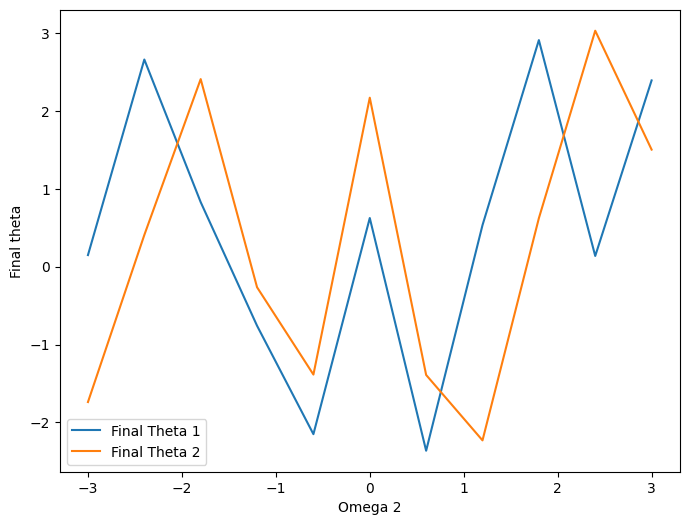

In [35]:
# Double pendulum, some interesting plots (not animation)
from matplotlib.pyplot import plot,show,figure,xlabel,ylabel,legend
from math import sin,cos,pi
from numpy import arange,array,clip

# Function f(r)
def f(r,l):
  # gravity
  g = 9.81
  # init conditions for pos r[0] and r[1] ; vel r[2] and r[3]
  theta1 = r[0]
  theta2 = r[1]
  omega1 = r[2]
  omega2 = r[3]
  # ftheta1 = omega1
  # ftheta2 = omega2

  theta1 = clip(theta1, -2*pi, 2*pi)
  theta2 = clip(theta2, -2*pi, 2*pi)

  # ODEs -- derivs of omega1 and omega2 i.e. accelerations
  fomega1 = -(omega1*omega1*sin(2*theta1-2*theta2) + 2*omega2*omega2*sin(theta1-theta2) + (3*sin(theta1) + sin(theta1-2*theta2))*g/l)/(3-cos(2*theta1-2*theta2))
  fomega2 = (4*omega1*omega1*sin(theta1-theta2) + omega2*omega2*sin(2*theta1-2*theta2) - 2*(sin(theta2)-sin(2*theta1-theta2))*g/l)/(3-cos(2*theta1-2*theta2))

  return array([omega1,omega2,fomega1,fomega2],float)


# Main Program from arbitrary starting values
def runDoublePendulum(theta1,theta2,omega1,omega2,tf=50.,nstep=100,l = 1):
  t = 0
  h = (tf-t)/nstep / 32
  r = array([theta1,theta2,omega1,omega2])
  thetas_1 = []
  thetas_2 = []
  omegas_1 = []
  omegas_2 = []

  # Main loop
  while t < tf:
      ### fix values so we're not sensitive to 2pi wrap

      r[0] = (r[0] + pi) % (2 * pi) - pi
      r[1] = (r[1] + pi) % (2 * pi) - pi

      thetas_1.append(r[0])
      thetas_2.append(r[1])
      omegas_1.append(r[2])
      omegas_2.append(r[3])

      # 4th-order RK
      k1 = h*f(r,l)
      k2 = h*f(r+0.5*k1,l)
      k3 = h*f(r+0.5*k2,l)
      k4 = h*f(r+k3,l)
      r += (k1+2*k2+2*k3+k4)/6

      # Update
      t += h
      print(f"t: {t}, theta1: {r[0]}, theta2: {r[1]}, omega1: {r[2]}, omega2: {r[3]}")

  return (thetas_1, thetas_2, omegas_1, omegas_2)

thetas_1, thetas_2, _, _ = 2.0, 2.0, 0.3, 0.0
omegas_2_vals = arange(-3, 3.1, 0.6)

final_thetas_1 = []
final_thetas_2 = []

for omegas_2 in omegas_2_vals:
  thetas_1, thetas_2, _, _ = runDoublePendulum(2.0, 2.0, 0.3, omegas_2)

  # need to get final values of thetas
  final_thetas_1.append(thetas_1[-1])
  final_thetas_2.append(thetas_2[-1])

figure(figsize=(8,6))
plot(omegas_2_vals, final_thetas_1, label="Final Theta 1")
plot(omegas_2_vals, final_thetas_2, label="Final Theta 2")
xlabel("Omega 2")
ylabel("Final theta")
legend()
show()


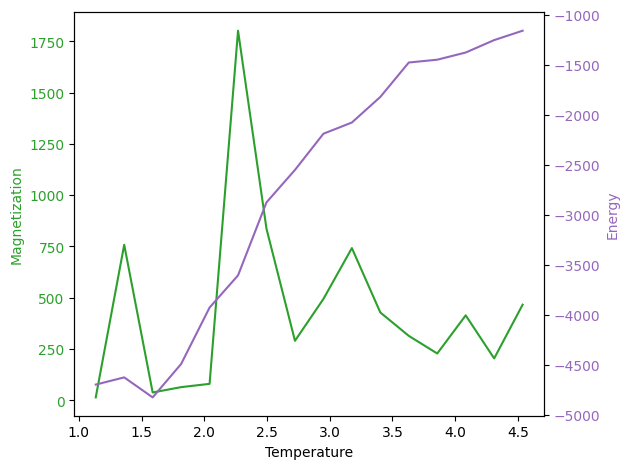

In [ ]:
# 50 x 50 Ising Model -- Mag and Energy v Temp
# I essentially changed up the code from slides 126-128 of ch.10 notes
# I have included two funcs: lattice() and  monte_c()

from math import exp
from numpy import empty, sum, arange
from random import random, randrange
from pylab import plot, show, xlabel, ylabel, subplots

# params
L = 50
N = 1000000
J = 1.0
Tc = 2.269 * J


# lattice func.
# lattice points i.e. spin values -- either +1 or -1
# need 50 by 50
def lattice():
    s = empty([L,L], int)
    for i in range(L):
        for j in range(L):
            if random() < 0.5:
                s[i,j] = 1
            else:
                s[i,j] = -1
    return s


# energy func.
# loop through rows and columns of lattice points (spins)
# add spin values and multiply by strength between lattice points, J, rather -J
def energy(s):
    return -J * (sum(s[0:L-1,:]*s[1:L,:]) + sum(s[:,0:L-1]*s[:,1:L]))



# monte_c func.
def monte_c (T):
    s = lattice()
    E = energy(s)
    M = abs(sum(s))

    for k in range(N):

        # save energy and mag before spin flip
        oldE = E
        oldMag = M

        # choose a random spin
        i = randrange(L)
        j = randrange(L)

        # considering spins above (iup), below (idown),  right (jup), left (jdown)
        # '% L' to stay between [0,L]
        iup = (i+1) % L
        idown = (i-1) % L
        jup = (j+1) % L
        jdown = (j-1) % L

        # change in energy: deltaE
        # (2) comes from (1 - (-1) = 2)
        deltaE = 2 * J * s[i,j]*(s[iup,j]+s[idown,j]+s[i,jup]+s[i,jdown])

        # if deltaE < 0 or random number < Boltzmann const.
        # no transistion to higher energy
        if deltaE < 0 or random() < exp(-deltaE / T):
            s[i,j] *= -1

            # update energy and mag
            E += deltaE
            M = abs(oldMag + 2 * s[i,j])

    return M, E


# getting 5 temp values to plot -- k should be between (0.5 - 2)
# setting up lists to use for "pretty" plotting: mag and energy v temp
temps = [Tc * k for k in arange(0.5, 2.1, 0.1)]
mag_vals = []
energy_vals = []


# loop through temps -- send through monte_c func.
# add vals to mag and energy lists to use for plotting
for T in temps:
    M, E = monte_c(T)
    mag_vals.append(M)
    energy_vals.append(E)


# setting up first plot
fig, ax1 = subplots()

# magnetization
color = 'tab:green'
ax1.set_xlabel('Temperature')
ax1.set_ylabel('Magnetization', color=color)
ax1.plot(temps, mag_vals, color=color)
ax1.tick_params(axis='y', labelcolor=color)


# setting up second plot
ax2 = ax1.twinx()

# energy
color = 'tab:purple'
ax2.set_ylabel('Energy', color=color)
ax2.plot(temps, energy_vals, color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
show()

# looks good, though I wonder if my plots should be smoother?

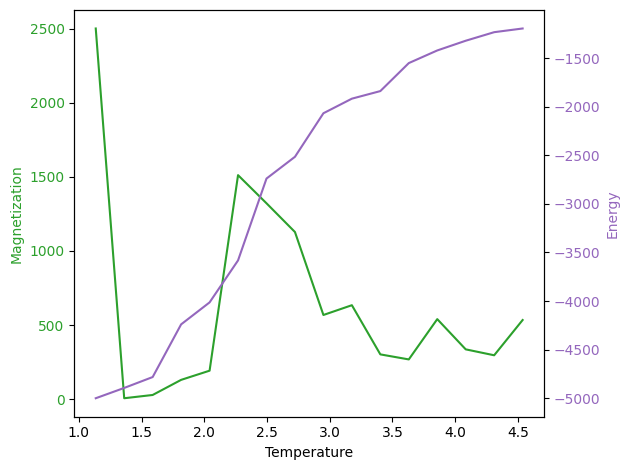

In [ ]:
# 50 x 50 Ising Model -- Mag and Energy v Temp
# Included External Mag. Field H = 1.0

from math import exp
from numpy import empty, sum, arange
from random import random, randrange
from pylab import plot, show, xlabel, ylabel, subplots

# params
L = 50
N = 1000000
J = 1.0
Tc = 2.269 * J
H = 1.0


# lattice func.
# lattice points i.e. spin values -- either +1 or -1
# need 50 by 50
def lattice():
    s = empty([L,L], int)
    for i in range(L):
        for j in range(L):
            if random() < 0.5:
                s[i,j] = 1
            else:
                s[i,j] = -1
    return s


# energy func.
# loop through rows and columns of lattice points (spins)
# add spin values and multiply by strength between lattice points, J, rather -J
def energy(s,H):
    return -J * (sum(s[0:L-1,:]*s[1:L,:]) + sum(s[:,0:L-1]*s[:,1:L])) - H * sum(s)



# monte_c func.
def monte_c (T,H):
    s = lattice()
    E = energy(s,H)
    M = abs(sum(s))

    for k in range(N):

        # save energy and mag before spin flip
        oldE = E
        oldMag = M

        # choose a random spin
        i = randrange(L)
        j = randrange(L)

        # considering spins above (iup), below (idown),  right (jup), left (jdown)
        # '% L' to stay between [0,L]
        iup = (i+1) % L
        idown = (i-1) % L
        jup = (j+1) % L
        jdown = (j-1) % L

        # change in energy: deltaE
        # (2) comes from (1 - (-1) = 2)
        deltaE = 2 * J * s[i,j]*(s[iup,j]+s[idown,j]+s[i,jup]+s[i,jdown])

        # if deltaE < 0 or random number < Boltzmann const.
        # no transistion to higher energy
        if deltaE < 0 or random() < exp(-deltaE / T):
            s[i,j] *= -1

            # update energy and mag
            E += deltaE
            M = abs(oldMag + 2 * s[i,j])

    return M, E


# getting 5 temp values to plot -- k should be between (0.5 - 2)
# setting up lists to use for "pretty" plotting: mag and energy v temp
temps = [Tc * k for k in arange(0.5, 2.1, 0.1)]
mag_vals = []
energy_vals = []


# loop through temps -- send through monte_c func.
# add vals to mag and energy lists to use for plotting
for T in temps:
    M, E = monte_c(T,H)
    mag_vals.append(M)
    energy_vals.append(E)


# setting up first plot
fig, ax1 = subplots()

# magnetization
color = 'tab:green'
ax1.set_xlabel('Temperature')
ax1.set_ylabel('Magnetization', color=color)
ax1.plot(temps, mag_vals, color=color)
ax1.tick_params(axis='y', labelcolor=color)


# setting up second plot
ax2 = ax1.twinx()

# energy
color = 'tab:purple'
ax2.set_ylabel('Energy', color=color)
ax2.plot(temps, energy_vals, color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
show()

# Results

# The energy is slightly effected with ext. mag. field
# Magnetization is absolutely effected with ext. mag. field

In [ ]:
!pip install parton

from google.colab import drive
drive.mount('/content/drive')

from parton import mkPDF
pdf = mkPDF('CT10', 0, pdfdir='/content/drive/My Drive/')

print("PDF check value for up quark, x = 0.01, q^2 = 100*100 GeV^2", pdf.xfxQ2(2,0.01,100*100))

Mounted at /content/drive
PDF check value for up quark, x = 0.01, q^2 = 100*100 GeV^2 0.7673892631967593


total xs (barns) =  8.751495071097512e-15


<ipython-input-33-bc7f104f1f86>:148: RuntimeWarning: invalid value encountered in sqrt
  sqrt_s = np.sqrt(cosThetas * ebeam_cm**2)


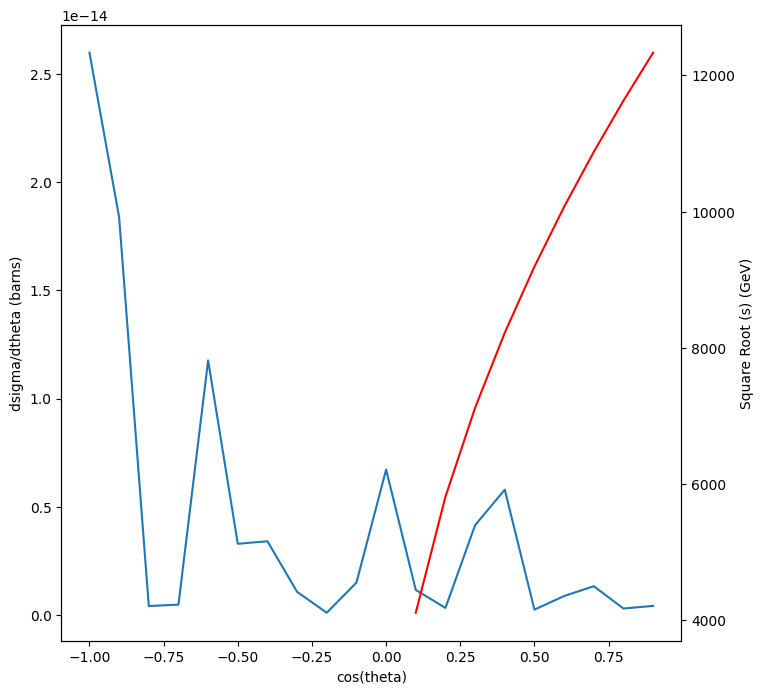

In [ ]:
# Importance Sampling

import numpy as np
from parton import mkPDF
import itertools
import matplotlib.pyplot as plt
from numpy.random import default_rng

def getQ_T3_NC(pdgID):
  q = 0 ## electric charge in units of e
  t3 = 0 ## t3  weak isospin
  nc = 1 ## number of colors
  if abs(pdgID) < 7: nc = 3
  if (pdgID == 2 or pdgID == 4 or pdgID == 6): ## up type quark
      q = 2./3
      t3 = 0.5
  elif (pdgID == -2 or pdgID == -4 or pdgID == -6): ## up type anti-quark
      q = -2./3
      t3 = -0.5
  elif (pdgID == 1 or pdgID == 3 or pdgID == 5): ## down type quark
      q = -1./3
      t3 = -0.5
  elif (pdgID == -1 or pdgID == -3 or pdgID == -5): ## down type anti0quark
      q = 1./3
      t3 = 0.5
  elif (pdgID == 11 or pdgID == 13 or pdgID == 15): ## charged lep
      q = -1.0
      t3 = -0.5
  elif (pdgID == -11 or pdgID == -13 or pdgID == -15): ## charged anti-lep
      q = 1.0
      t3 = 0.5
  elif (pdgID == 12 or pdgID == 14 or pdgID == 16): ## neutrino
      q = 0.0
      t3 = 0.5
  elif (pdgID == -12 or pdgID == -14 or pdgID == -16): ## anti neutrino
      q = 0.0
      t3 = -0.5
  return q,t3,nc


rng = default_rng()
pdf = mkPDF('CT10', 0,pdfdir='/content/drive/My Drive/')
q2=100.*100. ## 100^2 GeV^2
ebeam_cm = 13e3 ### 13 TeV = 13e3 GeV

dcosTheta = 0.1 ### binning for dcostheta
cosThetas = np.arange(-1,1,dcosTheta)

MZ = 91.1876;      # GeV
GF = 1.1663787e-5; # 1/GeV^2
sin2ThetaW = 0.23126;
Gamma_Z = 2.4952;

c2 = 8*GF*MZ*MZ / np.sqrt(2);

dsigmas = np.zeros(cosThetas.size)
q_o1,t3_o1,nc_o1 = getQ_T3_NC(11) ## electron
Le =  ( t3_o1-sin2ThetaW*q_o1);
Re = -1*(sin2ThetaW*q_o1);
pi2 = np.pi*np.pi
mz2 = MZ*MZ
convert_InvGeVGeV = 0.0003891 ### Converts GeV^-2 to barns

# xvals = np.array([0.00001, 0.00002, 0.00004, 0.0008, 0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009, \
#                   0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95])

pdgs = [1,2,3,4,5,-1,-2,-3,-4,-5]
labels = ['d','u','s','c','b','dbar','ubar','sbar','cbar','bbar']
fig = plt.figure(figsize=(8,8))


### I have only added to the code below
### Everything above has not been touched, with exception of commenting out xvals

for (lbl,pdg) in zip(labels,pdgs):
    # list to store values
    vals = []

    # list to store important values
    weights = []

    # performing IS on strange, charm, down, and up quark flavors
    if lbl in ['s', 'c', 'dbar', 'ubar', 'sbar', 'cbar', 'bbar']:
      for x in range(20000): # I just picked a random number of steps
          while True:
            x = rng.uniform(0.000001, 0.95) # easier eay to define xvals
            xpdf = pdf.xfxQ2(pdg, x, q2)
            if xpdf > 0:
              break
          # adding values to approp. lists
          vals.append(x)
          weights.append(xpdf)

    # turning lists to arrays
    npvals = np.array(vals)
    npweights = np.array(weights)

    # plotting
    # plt.plot(npvals, npweights,label=lbl, alpha=0.5)

# # plotting params
# plt.xlabel('x')
# plt.ylabel('x*PDF')
# plt.xscale('log')
# plt.yscale('log')
# plt.legend()
# plt.show()

n = 1000 ### BIG
xs = 0 ## total

for icosTheta,cosTheta in enumerate(cosThetas):
   dsigma_domega = 0
   for flavor in pdgs:
        if (flavor < 0): continue ### don't duplicate antiparticles
        # print("costheta = ",cosTheta,"flavor =",flavor,"total xs=",xs)
        q_i1,t3_i1,nc_i1 = getQ_T3_NC(flavor) ## quark
        L = t3_i1-sin2ThetaW*q_i1;
        R = -1*(sin2ThetaW*q_i1);
        for i in range(n):
          randx1 = rng.uniform(0.000001, 0.95)
          randx2 = rng.uniform(0.000001, 0.95)
          pdf1 = pdf.xfxQ2(flavor, randx1, q2)
          pdf2 = pdf.xfxQ2(-flavor, randx2, q2)

          ### assume no perpendicular motion and each proton carrying energy ebeam_cm / 2
          ### also, partons are massless given these energies, so |\vec{p}| = E
          ### then p1 = (0,0,-kx1, kx1) and p2 = (0,0,kx2,kx2) where k = ebeam_cm / 2
          ### then (p1+p2) = (0,0,k(x2-x1),k(x2+x1)) and s = (p1+p2)^2 = k^2[(x2+x1)^2 - (x2-x1)^2] = 4k^2x1x2
          ### And k^2 = ebeam_cm^2/4 so s = x1*x2*ebeam_cm^2
          s = randx1*randx2*ebeam_cm*ebeam_cm

          dsigma_domega += 2*pdf1*pdf2*((nc_o1 /  nc_i1 ) * (s / ( 256. * pi2) ) / ( pow( s-mz2, 2.0) + s*Gamma_Z*Gamma_Z) ) * \
                            c2*c2* ( (L*L+R*R)*(Le*Le+Re*Re)*(1+cosTheta*cosTheta) + (L*L-R*R)*(Le*Le-Re*Re)*2*cosTheta )

   dsigmas[icosTheta] = convert_InvGeVGeV*dsigma_domega/ n
   xs += dsigmas[icosTheta] * dcosTheta


# cross-section plot
print("total xs (barns) = ",xs)
plt.clf()
plt.plot(cosThetas,dsigmas)
plt.xlabel("cos(theta)")
plt.ylabel("dsigma/dtheta (barns)")

# sqrt of (s) plot
sqrt_s = np.sqrt(cosThetas * ebeam_cm**2)
ax2 = plt.gca().twinx()
ax2.plot(cosThetas, sqrt_s, 'r-')
ax2.set_ylabel("Square Root (s) (GeV)")
plt.show()

### Results Discussed Below!

# my cos(thetas) plot is not as smooth as I know it needs to be
# I have tried to make it smoother by adjusting bin size, number of steps (n)
# I have also tried to change what to implment importance sampling on but it doesn't seem to smoothen things
# I understand that it is supposed to be smooth, just not sure what I'm doing wrong
# Maybe I implemented IS incorrectly...?
# I commented out the first plot of all the flavors as I didn't think it was needed
